## data preprocessing for figure creation

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob as glob
from pathlib import Path
import re
import os
import sys
from collections import defaultdict
import matplotlib as mpl
import matplotlib.lines as lines
from scipy.stats import spearmanr

In [2]:
def startfig(
        w=4, h=2, rows=1, columns=1, wrs=None, hrs=None, frameon=True, return_first_ax=True
):
    ratio = 0.393701  # 1 cm in inch
    myfigsize = (w * ratio, h * ratio)
    fig = plt.figure(figsize=(myfigsize))
    gs = mpl.gridspec.GridSpec(rows, columns, width_ratios=wrs, height_ratios=hrs)
    if return_first_ax == True:
        a = fig.add_subplot(gs[0, 0], frameon=frameon)
        return a, fig, gs
    else:
        return fig, gs

In [3]:
mylines = 0.75 # updated
mpl.rcParams['axes.linewidth'] = mylines # default 1
mpl.rcParams['ytick.direction'] = 'out' # default 'in'
mpl.rcParams['xtick.direction'] = 'out' # default 'in'
mpl.rcParams['xtick.major.size'] = 3.5 # default 4
mpl.rcParams['ytick.major.size'] = 3.5 # default 4
mpl.rcParams['xtick.major.width'] = mylines # default 0.5
mpl.rcParams['ytick.major.width'] = mylines # default 0.5
mpl.rcParams['grid.linewidth'] = mylines/1.5# default 0.5
mpl.rcParams['grid.color'] = '0.8' # default 'k'
mpl.rcParams['grid.linestyle'] = 'solid'# default ':'
mpl.rcParams['legend.frameon'] = False # default True
mpl.rcParams['font.family'] = 'Arial' # added
mpl.rcParams['figure.dpi']= 300
mpl.rc("savefig", dpi=300)
mpl.rcParams['pdf.fonttype'] = 42 # embed fonts as editable text in illustrator
mpl.rcParams['ps.fonttype'] = 42 # embed fonts as editable text in illustrator`

In [ ]:
project_dir = os.getcwd()
data_path = '/tcr_seq_data'
output_dir = '/outputs'
publication_dir = '/publication_figures'

In [ ]:
# load data 
patient_t_cell_df_dict = defaultdict(pd.DataFrame)

for path in glob.glob('/outputs/boxplot_cancer_types/*.csv'):
    name = os.path.basename(path).split("_")[0]
    patient_t_cell_df_dict[name] = pd.read_csv(path, index_col=0)

# patient_t_cell_df_dict["cd8"]


In [ ]:
df = patient_t_cell_df_dict['cd4']


patient_list = df.index
total_t_cells = df.total_cd4_cells
unique_t_cells = df.n_cd4
unique_t_cells_expanded = df.more_or_equal_to_2

Index(['n_cd4', 'tumor_type', 'more_or_equal_to_2', 'total_cd4_cells',
       'data_source', 'CD4'],
      dtype='object')

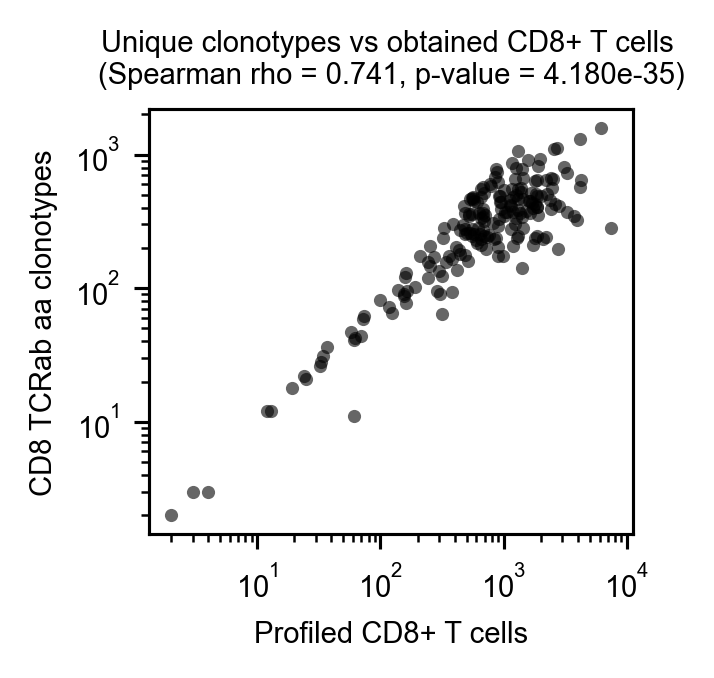

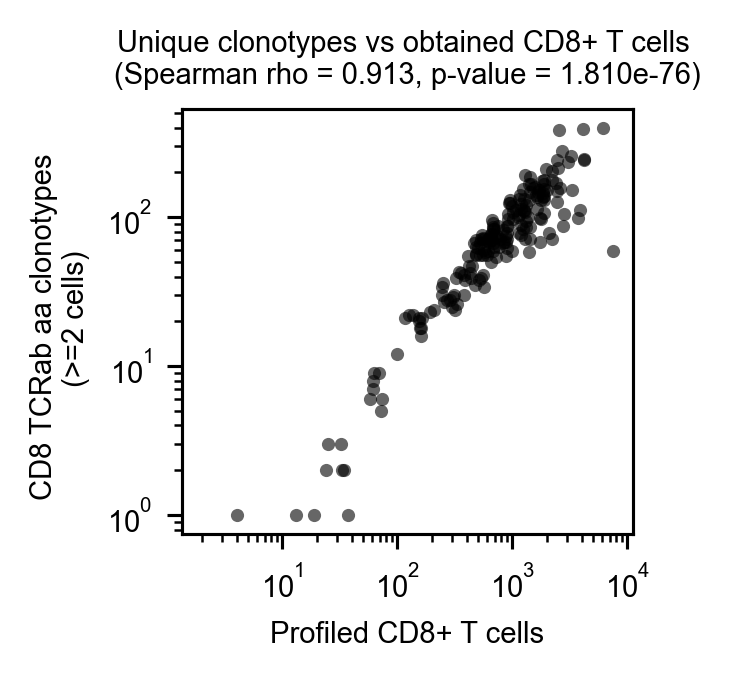

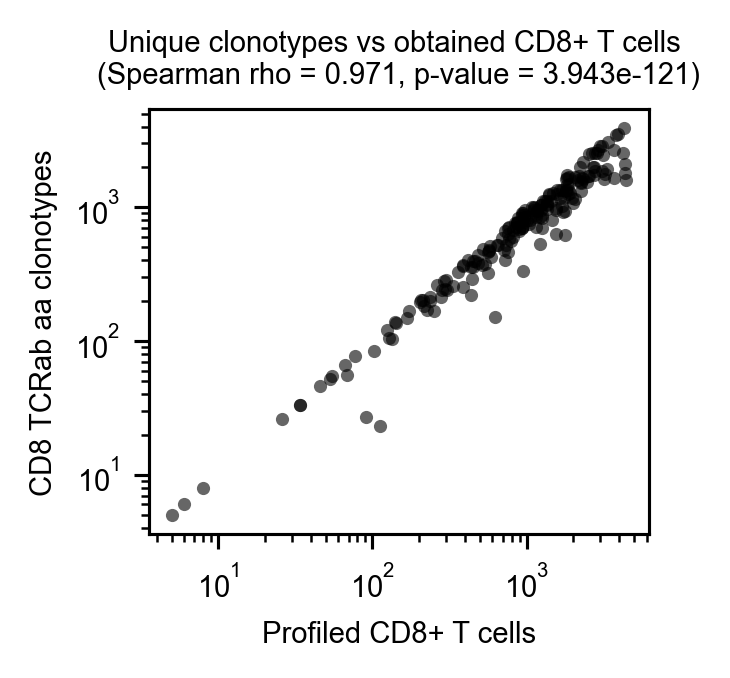

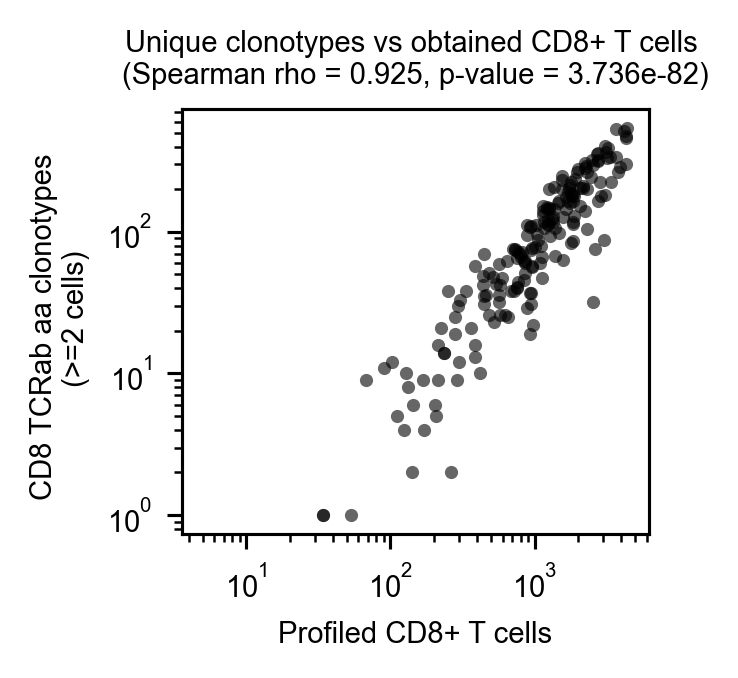

In [ ]:

fontsize=7

for key, df in patient_t_cell_df_dict.items():

    if key == 'cd4':
        patient_list = df.index
        total_t_cells = df.total_cd4_cells
        unique_t_cells = df.n_cd4
        unique_t_cells_expanded = df.more_or_equal_to_2

    if key == 'cd8':
        patient_list = df.index
        total_t_cells = df.total_cd8_cells
        unique_t_cells = df.n_cd8
        unique_t_cells_expanded = df.more_or_equal_to_2

    label = key.upper()

    for log in [True]:
        for metric in ['total_unique_clonotypes', 'unique_clonotypes_with_more_than_2_cells']:
            ax, fig, gs = startfig(6,6)

            if metric == 'total_unique_clonotypes':
                rho, pval = spearmanr(total_t_cells, unique_t_cells)
                ax.scatter(total_t_cells, unique_t_cells, s=10, color='black', alpha=0.6, linewidth=0)
                ax.set_ylabel(f"{label} TCRab aa clonotypes", fontsize=fontsize)
                ax.set_xlabel(f"Profiled {label}+ T cells", fontsize=fontsize)
                ax.set_title(f"Unique clonotypes vs obtained {label}+ T cells \n(Spearman rho = {rho:.3f}, p-value = {pval:.3e})", fontsize=fontsize)
                
                ax.tick_params(axis='both', which='major', labelsize=fontsize)

            elif metric == 'unique_clonotypes_with_more_than_2_cells':
                rho, pval = spearmanr(total_t_cells, unique_t_cells_expanded)
                ax.scatter(total_t_cells, unique_t_cells_expanded, s=10, color='black', alpha=0.6, linewidth=0)
                ax.set_ylabel(f"{label} TCRab aa clonotypes \n (>=2 cells)", fontsize=fontsize)
                ax.set_xlabel(f"Profiled {label}+ T cells", fontsize=fontsize)
                ax.set_title(f"Unique clonotypes vs obtained {label}+ T cells \n(Spearman rho = {rho:.3f}, p-value = {pval:.3e})", fontsize=fontsize)
                ax.tick_params(axis='both', which='major', labelsize=fontsize)

            if log:
                ax.set_xscale('log')
                ax.set_yscale('log')
                
            fig.tight_layout()

            if log: 
                fig.savefig(os.path.join(publication_dir, "scatters", f"new_{key}_scatter_{metric}_log.pdf"), dpi=300)

            plt.show()